# Customer Churn Prediction

## 1. Project Introduction

This project aims to predict whether a customer is likely to churn based on their demographic information, services, contract details, and billing information.

## 2. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## 3. Load the Dataset

In [3]:
df = pd.read_csv(r"D:\customer_churn_prediction\data\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 4. Understand the Dataset

In [4]:
#number of rows, number of columns

df.shape

(7043, 21)

### 4.1 View Column Names

In [5]:
#Column Names

df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

### 4.2 Understand the Columns

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### 4.3 Check Missing Values

In [8]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### 4.4 Check TotalCharges

In [9]:
df["TotalCharges"].head(20)

0       29.85
1      1889.5
2      108.15
3     1840.75
4      151.65
5       820.5
6      1949.4
7       301.9
8     3046.05
9     3487.95
10     587.45
11      326.8
12     5681.1
13     5036.3
14    2686.05
15    7895.15
16    1022.95
17    7382.25
18     528.35
19     1862.9
Name: TotalCharges, dtype: str

### 4.5 Convert TotalCharges to Numeric

In [10]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [11]:
df["TotalCharges"].isnull().sum()

np.int64(11)

### 4.6 Investigate Missing TotalCharges

In [12]:
df[df["TotalCharges"].isnull()][
    ["customerID","tenure","MonthlyCharges","TotalCharges"]
]

,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


### 4.7 Handle Missing TotalCharges

In [14]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)
df["TotalCharges"].isnull().sum()

np.int64(0)

## 5.1 Churn Distribution

Let's examine how many customers stayed and how many customers churned.

In [15]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

### Churn Percentage

Let's calculate the percentage of customers who stayed and churned.

In [16]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

### 5.1.1 Visualize Churn Distribution

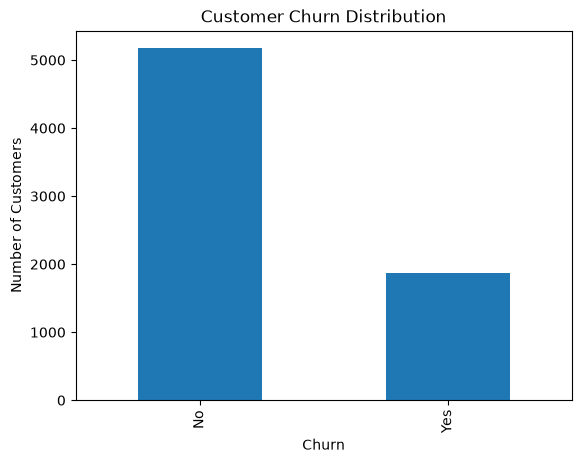

In [18]:
df["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

## 5.2 Numerical Features

Let's examine the basic statistics of the numerical features.

In [19]:
df[["SeniorCitizen","tenure","MonthlyCharges","TotalCharges"]].describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


### 5.2.1 Distribution of Numerical Features

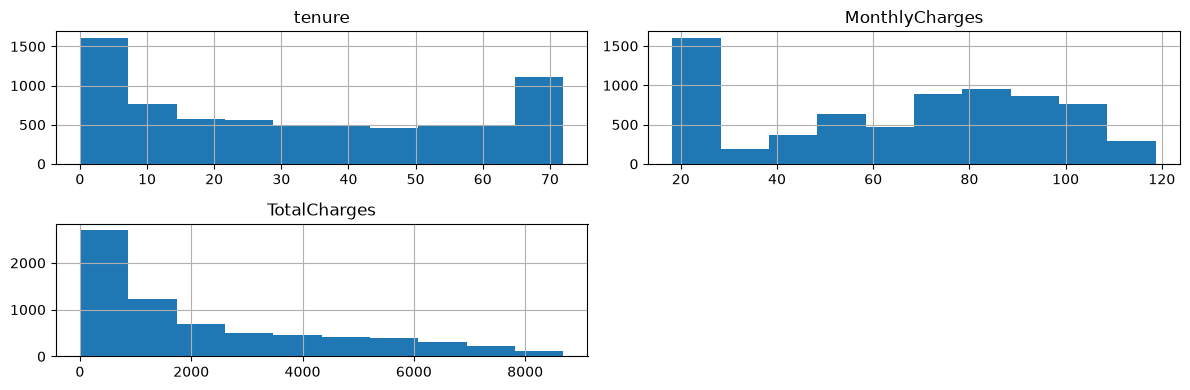

In [20]:
df[["tenure","MonthlyCharges","TotalCharges"]].hist(
    figsize=(12,4)
)
plt.tight_layout()

plt.show()

### 5.2.2 Tenure by Churn

In [21]:
df.groupby("Churn")["tenure"].mean()

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

### 5.2.3 Average Tenure by Churn

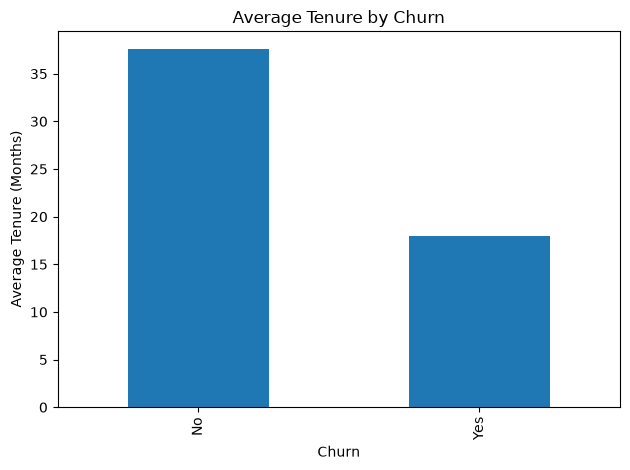

In [23]:
df.groupby("Churn")["tenure"].mean().plot(kind="bar")

plt.title("Average Tenure by Churn")
plt.xlabel("Churn")
plt.ylabel("Average Tenure (Months)")
plt.tight_layout()

plt.show()

### 5.2.4 Average Monthly Charges by Churn

In [24]:
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

In [25]:
df.groupby("Churn")["TotalCharges"].mean()

Churn
No     2549.911442
Yes    1531.796094
Name: TotalCharges, dtype: float64

### 5.2.5 Senior Citizen and Churn

In [26]:
pd.crosstab(df["SeniorCitizen"] , df["Churn"])

Churn,No,Yes
SeniorCitizen,,
0,4508,1393
1,666,476


### 5.2.6 Churn Rate by Senior Citizen Status

In [28]:
pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
SeniorCitizen,,
0,76.393832,23.606168
1,58.318739,41.681261


## 5.3 Categorical Features

### 5.3.1 Contract Type and Churn

In [29]:
pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


### 5.3.2 Churn Rate by Contract Type

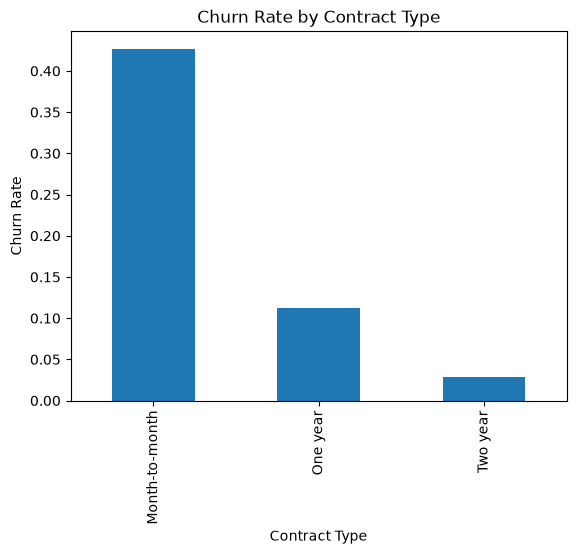

In [30]:
pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
)["Yes"].plot(kind="bar")

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate")

plt.show()

### 5.3.3 Internet Service and Churn

In [31]:
pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


### 5.3.4 Average Monthly Charges by Contract Type

In [32]:
df.groupby("Contract")["MonthlyCharges"].mean()

Contract
Month-to-month    66.398490
One year          65.048608
Two year          60.770413
Name: MonthlyCharges, dtype: float64

## 6. Prepare Data for Machine Learning

## 6.1 Separate Features and Target

We separate the input features from the target variable that we want the model to predict.

In [36]:
X = df.drop("Churn" , axis=1)
y = df["Churn"]

X.shape


(7043, 20)

In [37]:
y.shape

(7043,)

### 6.2 Train-Test Split

In [39]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5634, 20), (1409, 20), (5634,), (1409,))

### 6.3 Numerical Features

In [41]:
numerical_cols = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

numerical_cols

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

### 6.4 Categorical Features

In [42]:
categorical_cols = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

categorical_cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

### 6.5 Remove Customer ID

In [43]:
X = X.drop("customerID", axis=1)

In [44]:
X.shape

(7043, 19)

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5634, 19), (1409, 19), (5634,), (1409,))

### 6.6 Encoding Categorical Features

In [47]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown="ignore")

In [48]:
X_train[categorical_cols].head()

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod
3738,Male,No,No,No,No phone service,DSL,No,No,Yes,No,Yes,Yes,Month-to-month,No,Electronic check
3151,Male,Yes,Yes,Yes,No,Fiber optic,Yes,No,No,No,No,No,Month-to-month,No,Mailed check
4860,Male,Yes,Yes,No,No phone service,DSL,Yes,Yes,No,Yes,No,No,Two year,No,Mailed check
3867,Female,Yes,No,Yes,No,DSL,No,Yes,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic)
3810,Male,Yes,Yes,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,No,Electronic check


In [51]:
X_train_encoder = encoder.fit_transform(
    X_train[categorical_cols]
)

In [53]:
X_train_encoder.shape

(5634, 41)

### 6.8 Combine Numerical and Categorical Processing

In [54]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical",encoder,categorical_cols)
    ]
)

In [55]:
X_train_processed = preprocessor.fit_transform(X_train)

X_train_processed.shape

(5634, 41)

### 6.9 Add Numerical Feature Scaling

In [56]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [57]:
preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", scaler,numerical_cols),
        ("categorical", encoder,categorical_cols)
    ]
)

In [58]:
X_train_processed = preprocessor.fit_transform(X_train)

X_train_processed.shape

(5634, 45)

### 6.10 Process Test Data

In [59]:
X_test_processed = preprocessor.transform(X_test)

X_test_processed.shape

(1409, 45)

## 7. Train Logistic Regression Model

### 7.1 Import Logistic Regression

In [63]:
from sklearn.linear_model import LogisticRegression

### 7.2 Create the Logistic Regression Model

In [64]:
model = LogisticRegression(max_iter=1000)

In [65]:
model.fit(X_train_processed,y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

### 7.4 Make Predictions

In [66]:
y_pred = model.predict(X_test_processed)

In [67]:
y_pred[:10]

array(['No', 'Yes', 'No', 'No', 'No', 'Yes', 'No', 'No', 'No', 'No'],
      dtype=object)

### 9.1 Accuracy

In [68]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test,y_pred)
accuracy

0.8055358410220014

### 9.2 Confusion Matrix

In [69]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,y_pred)
cm

array([[926, 109],
       [165, 209]])

9.3 Precision

In [71]:
from sklearn.metrics import precision_score

precision = precision_score(
    y_test,
    y_pred,
    pos_label="Yes"
)
precision

0.6572327044025157

9.4 Recall

In [72]:
from sklearn.metrics import recall_score

recall = recall_score(
    y_test,
    y_pred,
    pos_label="Yes"
)
recall

0.5588235294117647

9.5 F1 Score


In [73]:
from sklearn.metrics import f1_score

f1 = f1_score(
    y_test,
    y_pred,
    pos_label="Yes"
)
f1

0.6040462427745664

# 10.Prediction Probability

In [74]:
probabilities = model.predict_proba(X_test_processed)
probabilities[:10]

array([[0.95408007, 0.04591993],
       [0.31628655, 0.68371345],
       [0.94106015, 0.05893985],
       [0.59816471, 0.40183529],
       [0.97857574, 0.02142426],
       [0.39702197, 0.60297803],
       [0.55237102, 0.44762898],
       [0.86966446, 0.13033554],
       [0.99719645, 0.00280355],
       [0.60526126, 0.39473874]])

In [75]:
model.classes_

array(['No', 'Yes'], dtype=object)

In [76]:
churn_probability = probabilities[:,1]
churn_probability[:10]

array([0.04591993, 0.68371345, 0.05893985, 0.40183529, 0.02142426,
       0.60297803, 0.44762898, 0.13033554, 0.00280355, 0.39473874])

In [77]:
results = pd.DataFrame({
    "Actual":y_test.values,
    "Predicted":y_pred,
    "churn_probability":churn_probability
})

results.head(10)

,Actual,Predicted,churn_probability
0,No,No,0.045920
1,No,Yes,0.683713
2,No,No,0.058940
3,No,No,0.401835
4,No,No,0.021424
5,No,Yes,0.602978
6,No,No,0.447629
7,No,No,0.130336
8,No,No,0.002804
9,Yes,No,0.394739
